<a href="https://colab.research.google.com/github/rehandg/Tute-Dude-Ds-Assignment-7/blob/main/Cardiac_Diagnostics_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving heart.csv to heart (2).csv
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   cho

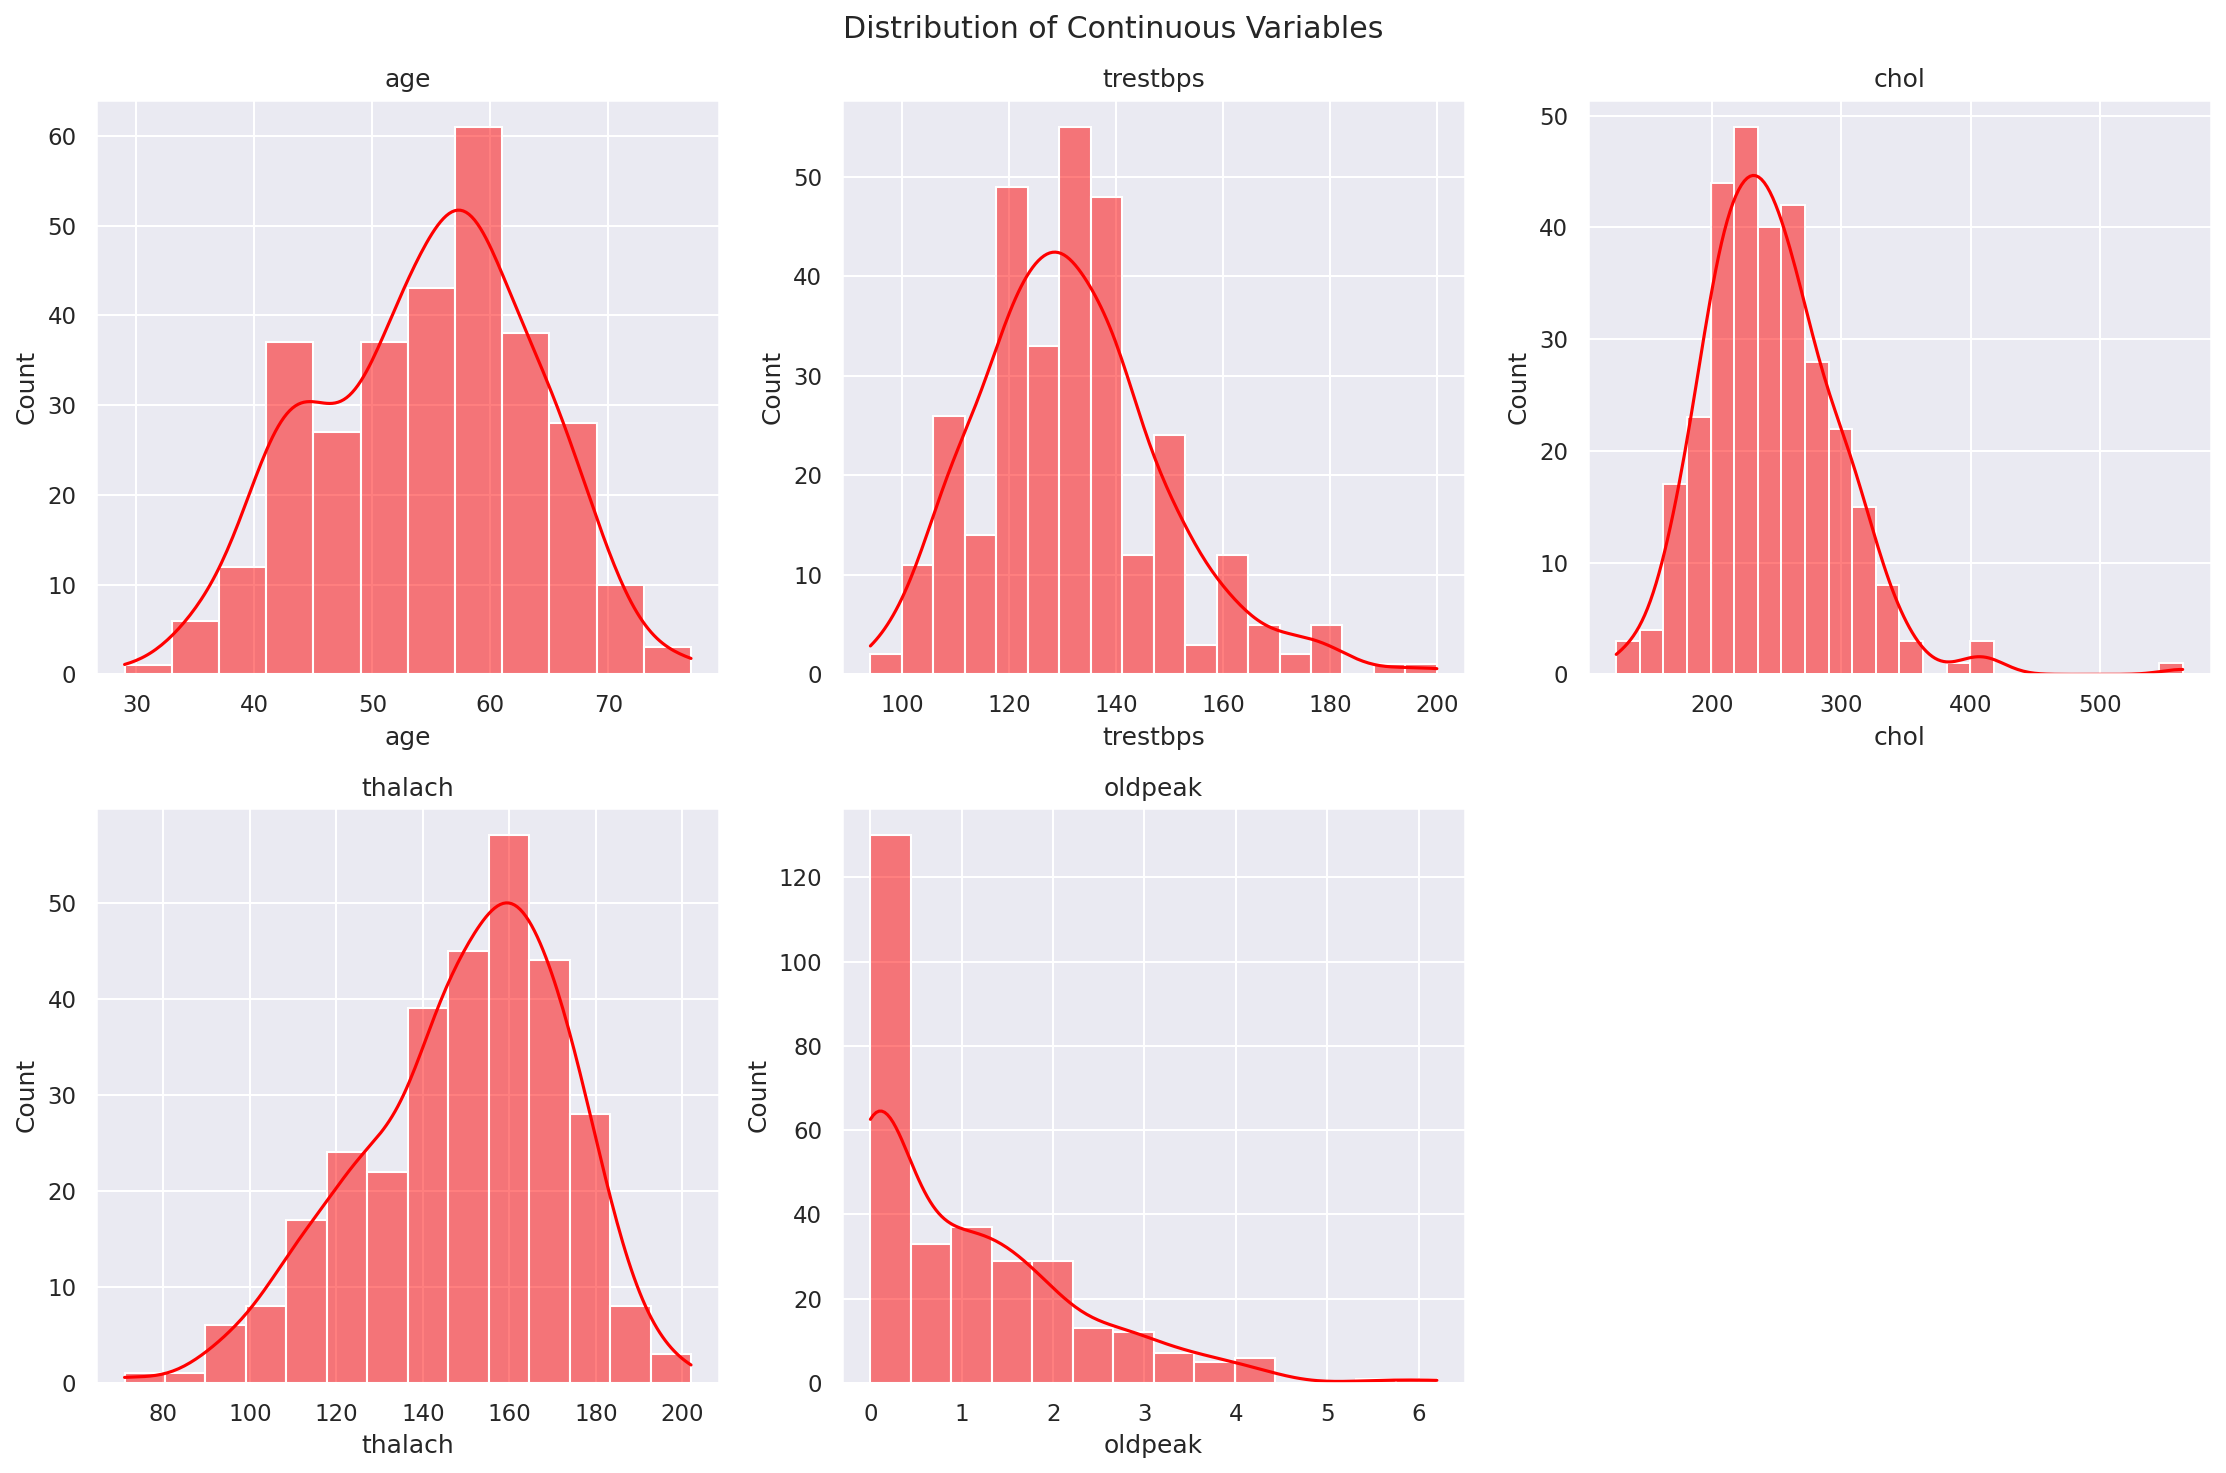

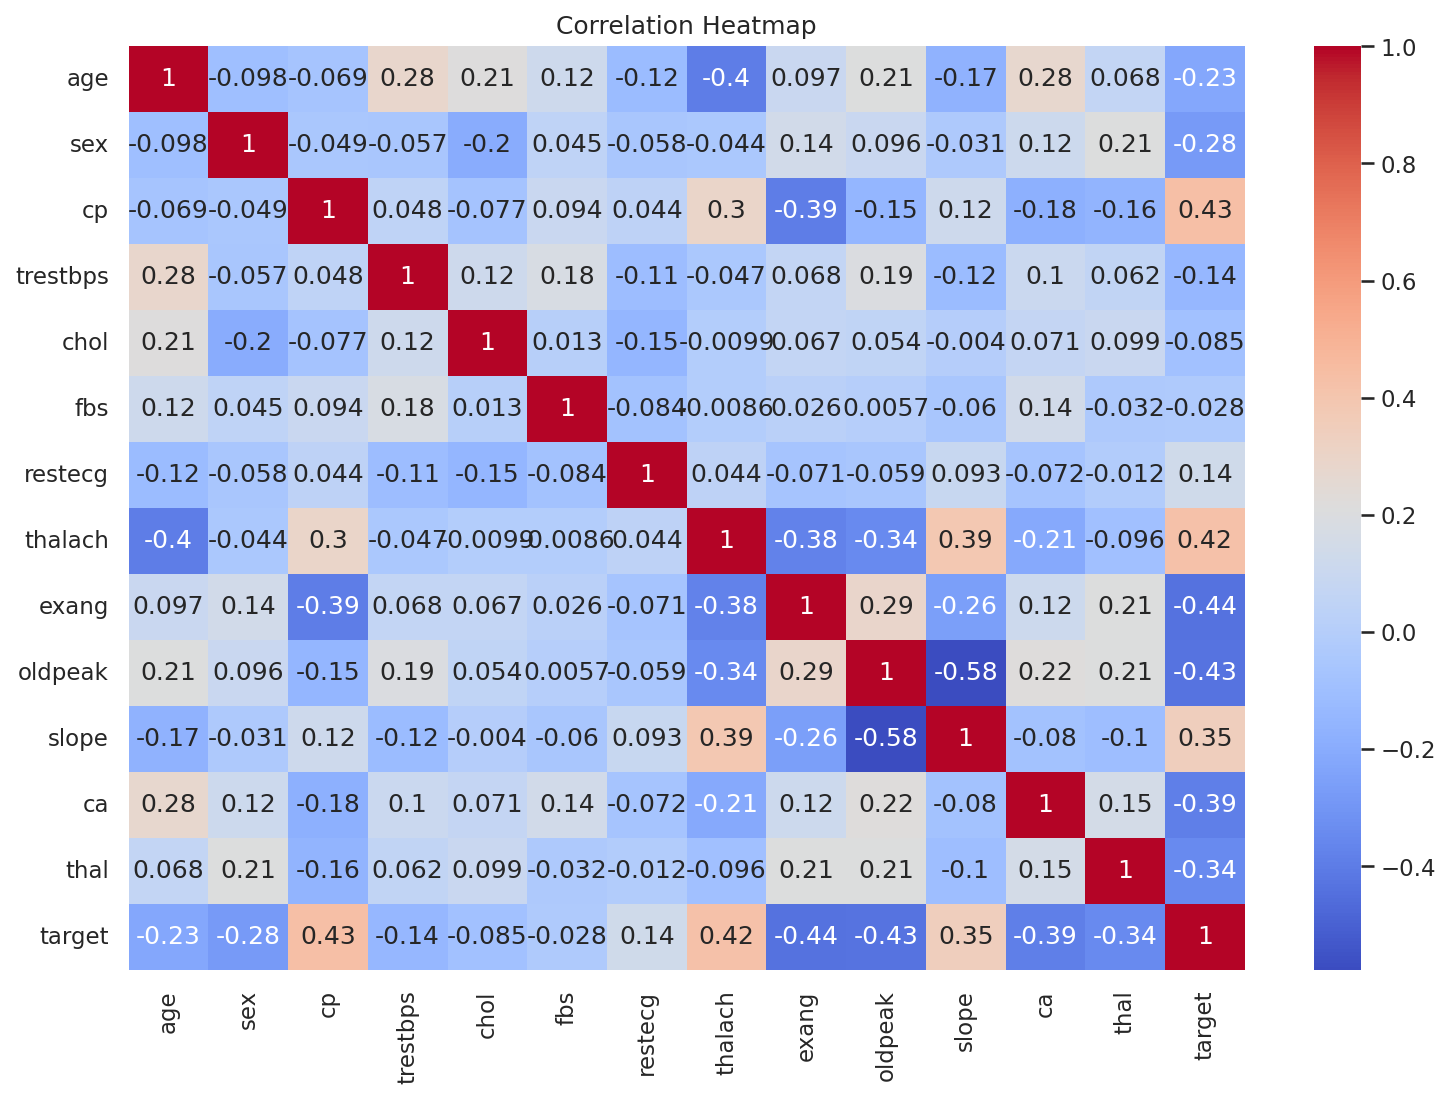


Model Evaluation
Accuracy: 0.8360655737704918
Precision: 0.8108108108108109
Recall: 0.9090909090909091
F1 Score: 0.8571428571428571

Confusion Matrix:
[[21  7]
 [ 3 30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        28
           1       0.81      0.91      0.86        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61



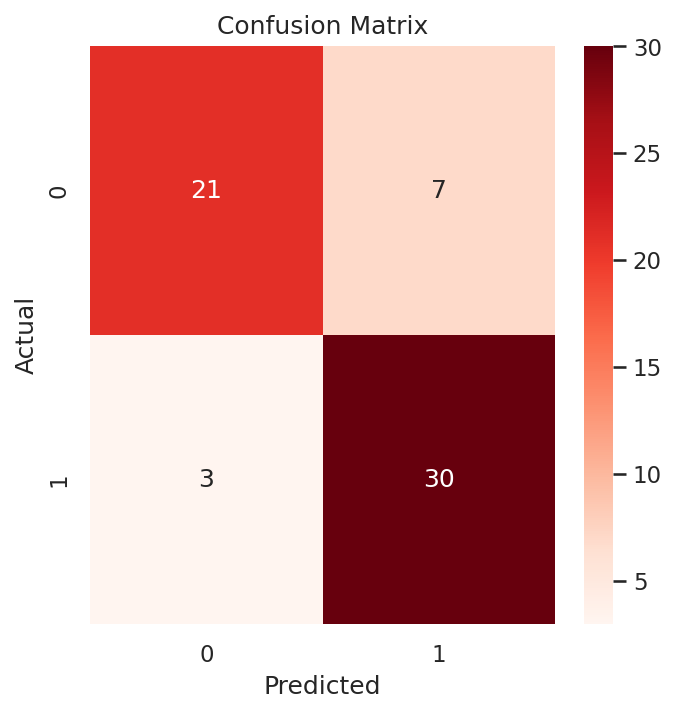

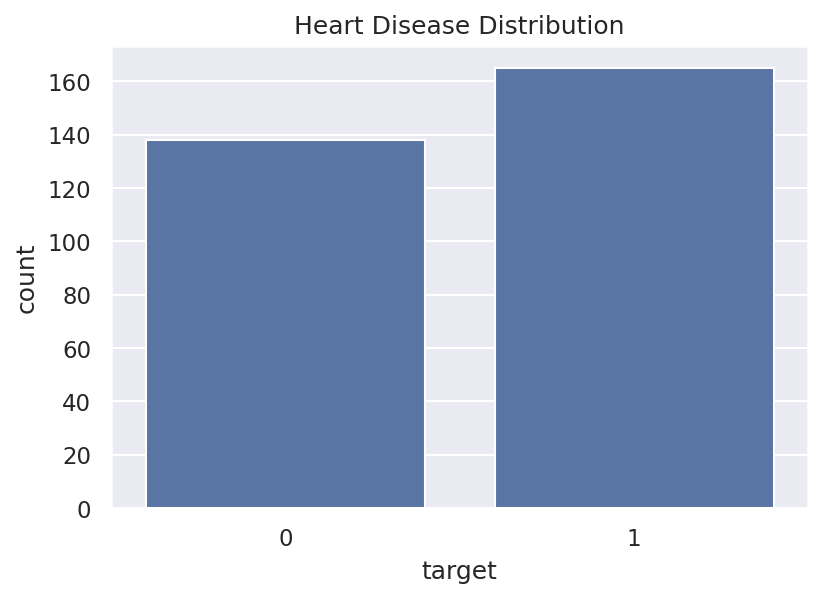


Analysis:
The dataset was explored and preprocessed before model training.
Categorical variables were encoded and numerical features were standardized.
Logistic Regression achieved good classification performance on the heart disease dataset.


In [4]:
from google.colab import files
uploaded = files.upload()

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression

# Read Dataset
df = pd.read_csv("heart.csv")

# Display First 5 Rows
print(df.head())

# Dataset Information
print(df.info())

# Statistical Summary
print(df.describe())

# Check Missing Values
print(df.isnull().sum())

# Set Plot Style
plt.rcParams['figure.dpi'] = 150
sns.set(style='darkgrid')

# Continuous Features
continuous_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

# Distribution of Continuous Features
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(continuous_features):

    row = i // 3
    col_idx = i % 3

    sns.histplot(
        df[col],
        kde=True,
        ax=ax[row, col_idx],
        color='red'
    )

    ax[row, col_idx].set_title(col)

ax[1, 2].axis('off')

plt.suptitle("Distribution of Continuous Variables")

plt.tight_layout()

plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# Handle Missing Values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Encode Categorical Variables
categorical_columns = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'thal'
]

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression Model
model = LogisticRegression()

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(5, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Target Distribution
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Heart Disease Distribution")

plt.show()

# Brief Analysis
print("\nAnalysis:")
print("The dataset was explored and preprocessed before model training.")
print("Categorical variables were encoded and numerical features were standardized.")
print("Logistic Regression achieved good classification performance on the heart disease dataset.")